# CISC7204 Assignment 01

**Submitted by:** Xiji Hang (MC646933).

## Module 03 · Lab 02 — Exploring laptop prices

**Collaborators:** Xiji Hang (MC646933) and Xiaoyu Guo (MC648131).  
**Contribution:** All laboratory work is completed jointly.

**Source:** Adapted from the supplied IBM / Skills Network teaching notebook; original author credits are retained below. The source template is preserved separately.

**Execution:** Local Anaconda / Jupyter; results in this working copy are generated by executing its code. Input: `laptop_pricing_dataset_mod2.csv`, the unchanged dataset snapshot specified by this lab.

**Dataset source:** [laptop_pricing_dataset_mod2.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv) (snapshot accessed 15 September 2026). Each row describes one laptop configuration with its specifications and listed price.

# **Hands-on lab: Exploratory Data Analysis - Laptops Pricing dataset**



In this lab, you will use the skills acquired throughout the module, to explore the effect of different features on the price of laptops.

# Objectives

After completing this lab you will be able to:

 - Visualize individual feature patterns
 - Run descriptive statistical analysis on the dataset
 - Use groups and pivot tables to find the effect of categorical variables on price
 - Use Pearson Correlation to measure the interdependence between variables

# Setup

Use pandas, NumPy, Matplotlib, seaborn and SciPy in the local Anaconda environment. No browser-specific installation is required.

### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_

In [1]:
# Figures use 300 DPI for readable high-resolution exports.
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 40)
pd.set_option('display.precision', 4)
def locate_dataset(filename):
    # Accept a flat submission, the bundle root, or the notebooks subfolder.
    folders = (Path.cwd(), Path.cwd() / 'datasets' / 'raw',
               Path.cwd().parent / 'datasets' / 'raw')
    for folder in folders:
        candidate = folder / filename
        if candidate.is_file():
            return candidate.resolve()
    searched = ', '.join(str(folder / filename) for folder in folders)
    raise FileNotFoundError(f'Missing required dataset {filename}. Searched: {searched}')

def output_root_for(data_file):
    folder = data_file.resolve().parent
    if folder.name == 'raw' and folder.parent.name == 'datasets':
        return folder.parent.parent
    return folder

DATA_FILE = locate_dataset('laptop_pricing_dataset_mod2.csv')
DATA = DATA_FILE.parent
OUTPUT_ROOT = output_root_for(DATA_FILE)
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | NumPy {np.__version__}')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.0)
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 300, 'axes.spines.top': False, 'axes.spines.right': False})

Python 3.14.6 | pandas 3.0.3 | NumPy 2.4.6


# Import the dataset

Read the supplied `mod2` CSV snapshot. The extra `Unnamed:` columns are exported row indices and are excluded from the analysis; `Price-binned` remains descriptive and is never treated as a predictor of price.

In [2]:
file_path = DATA / 'laptop_pricing_dataset_mod2.csv'
file_name = file_path

Import the file to a pandas dataframe.

In [3]:
df = pd.read_csv(file_name, header=0)
export_index_columns = [c for c in df.columns if c.startswith('Unnamed:')]
print('CSV export-index columns excluded:', export_index_columns)
df = df.drop(columns=export_index_columns)
print(f'Analysis snapshot: {len(df)} rows × {df.shape[1]} columns.')

CSV export-index columns excluded: ['Unnamed: 0.1', 'Unnamed: 0']
Analysis snapshot: 238 rows × 14 columns.


Print the first 5 entries of the dataset to confirm loading.

In [4]:
df.head(5)

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.5517,8,256,3.5280,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.6897,4,256,4.8510,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.9310,8,256,4.8510,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.5517,8,128,2.6901,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.6207,8,256,4.2115,837,Low,1,0


# Task 1 - Visualize individual feature patterns

### Continuous valued features
Generate regression plots for each of the parameters "CPU_frequency", "Screen_Size_inch" and "Weight_pounds" against "Price". Also, print the value of correlation of each feature with "Price".

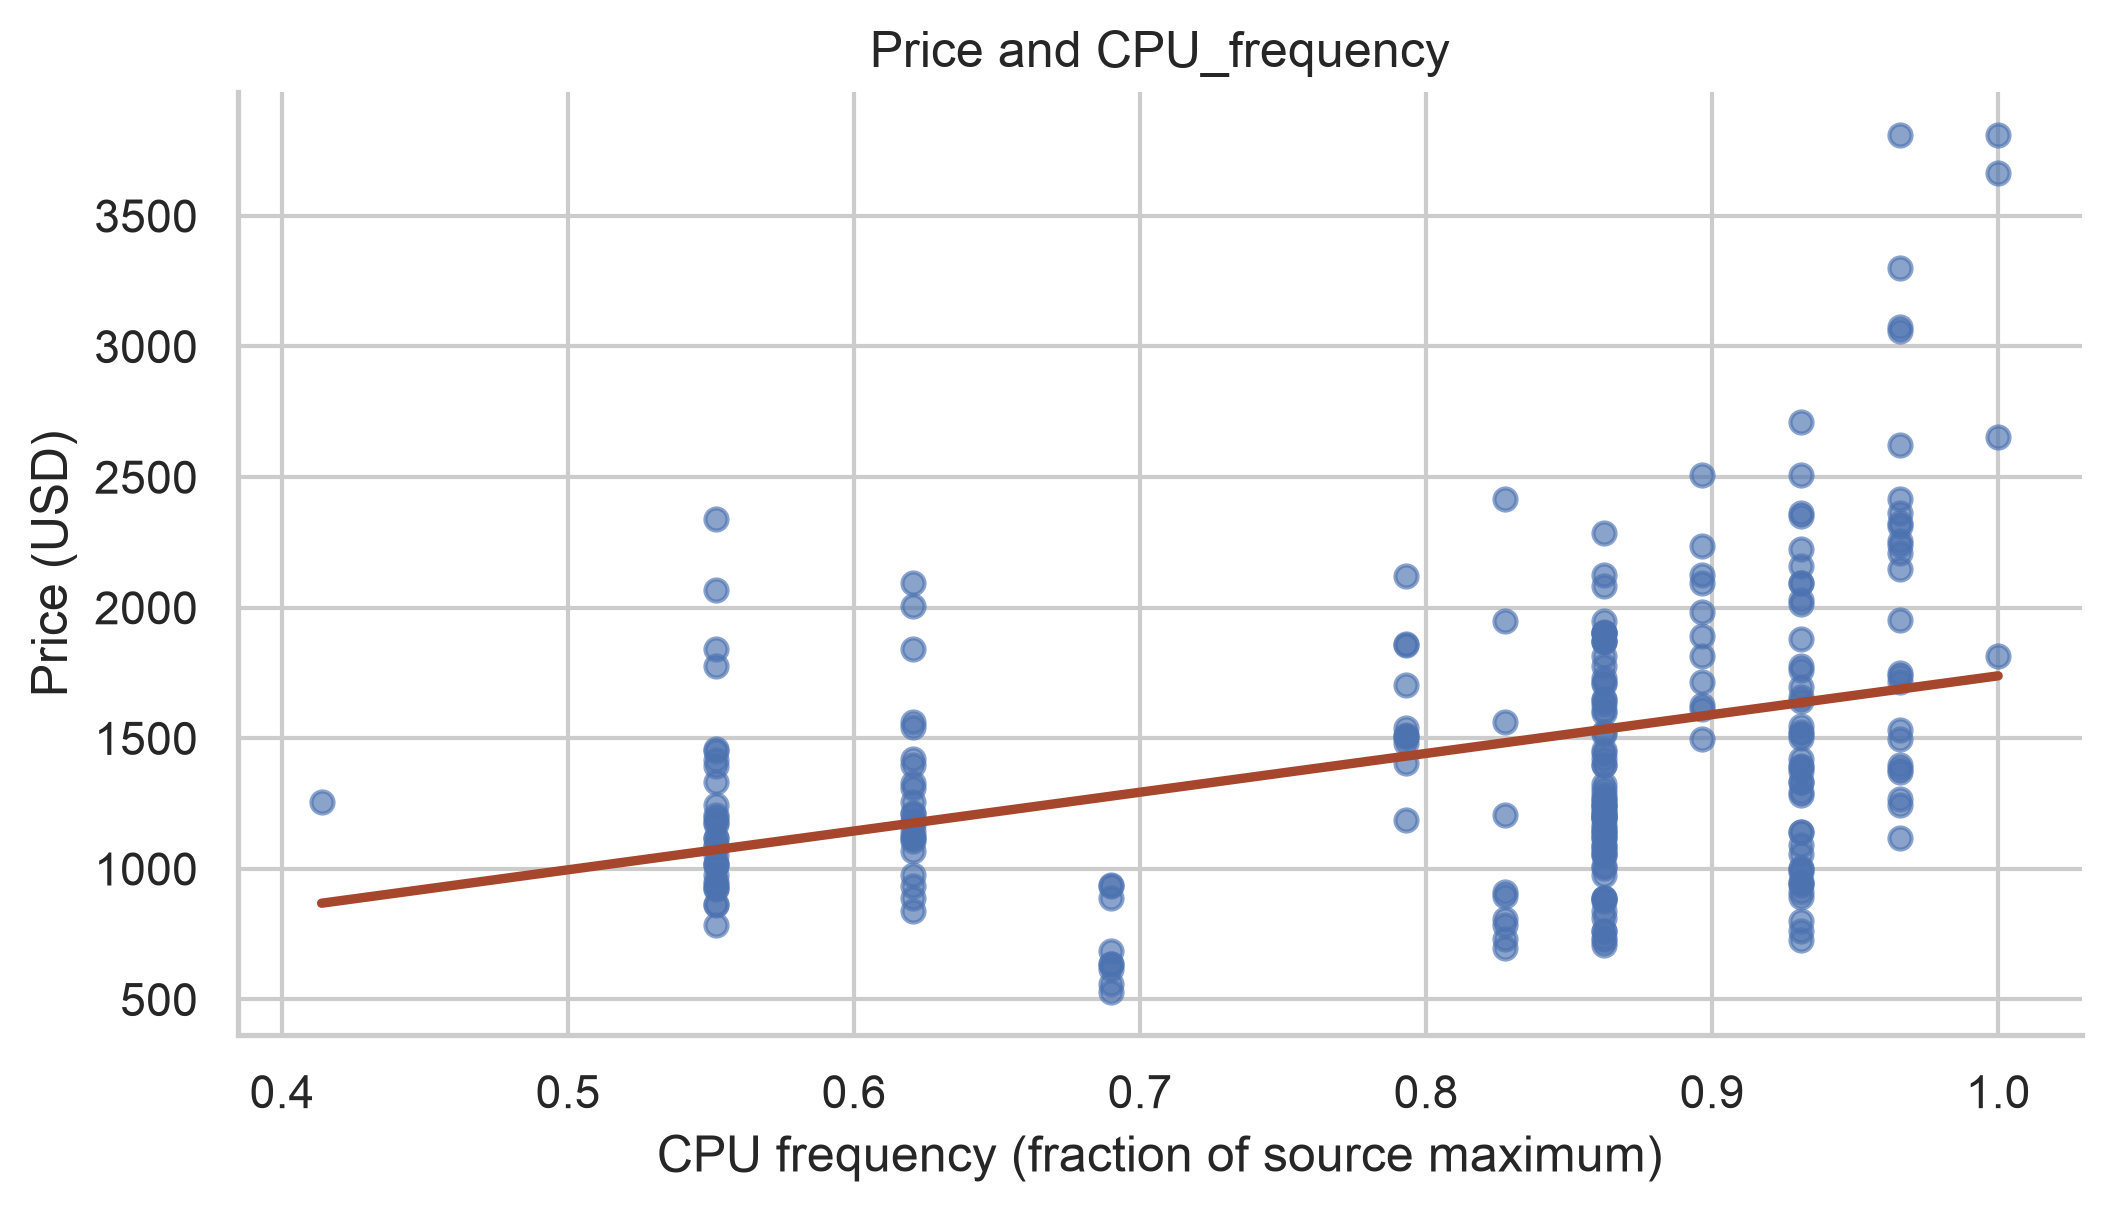

In [5]:
fig, ax = plt.subplots()
sns.regplot(data=df, x='CPU_frequency', y='Price', ci=None,
            scatter_kws={'alpha': 0.65, 's': 28}, line_kws={'color': '#a6462d'}, ax=ax)
ax.set(title='Price and CPU_frequency', xlabel='CPU frequency (fraction of source maximum)', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

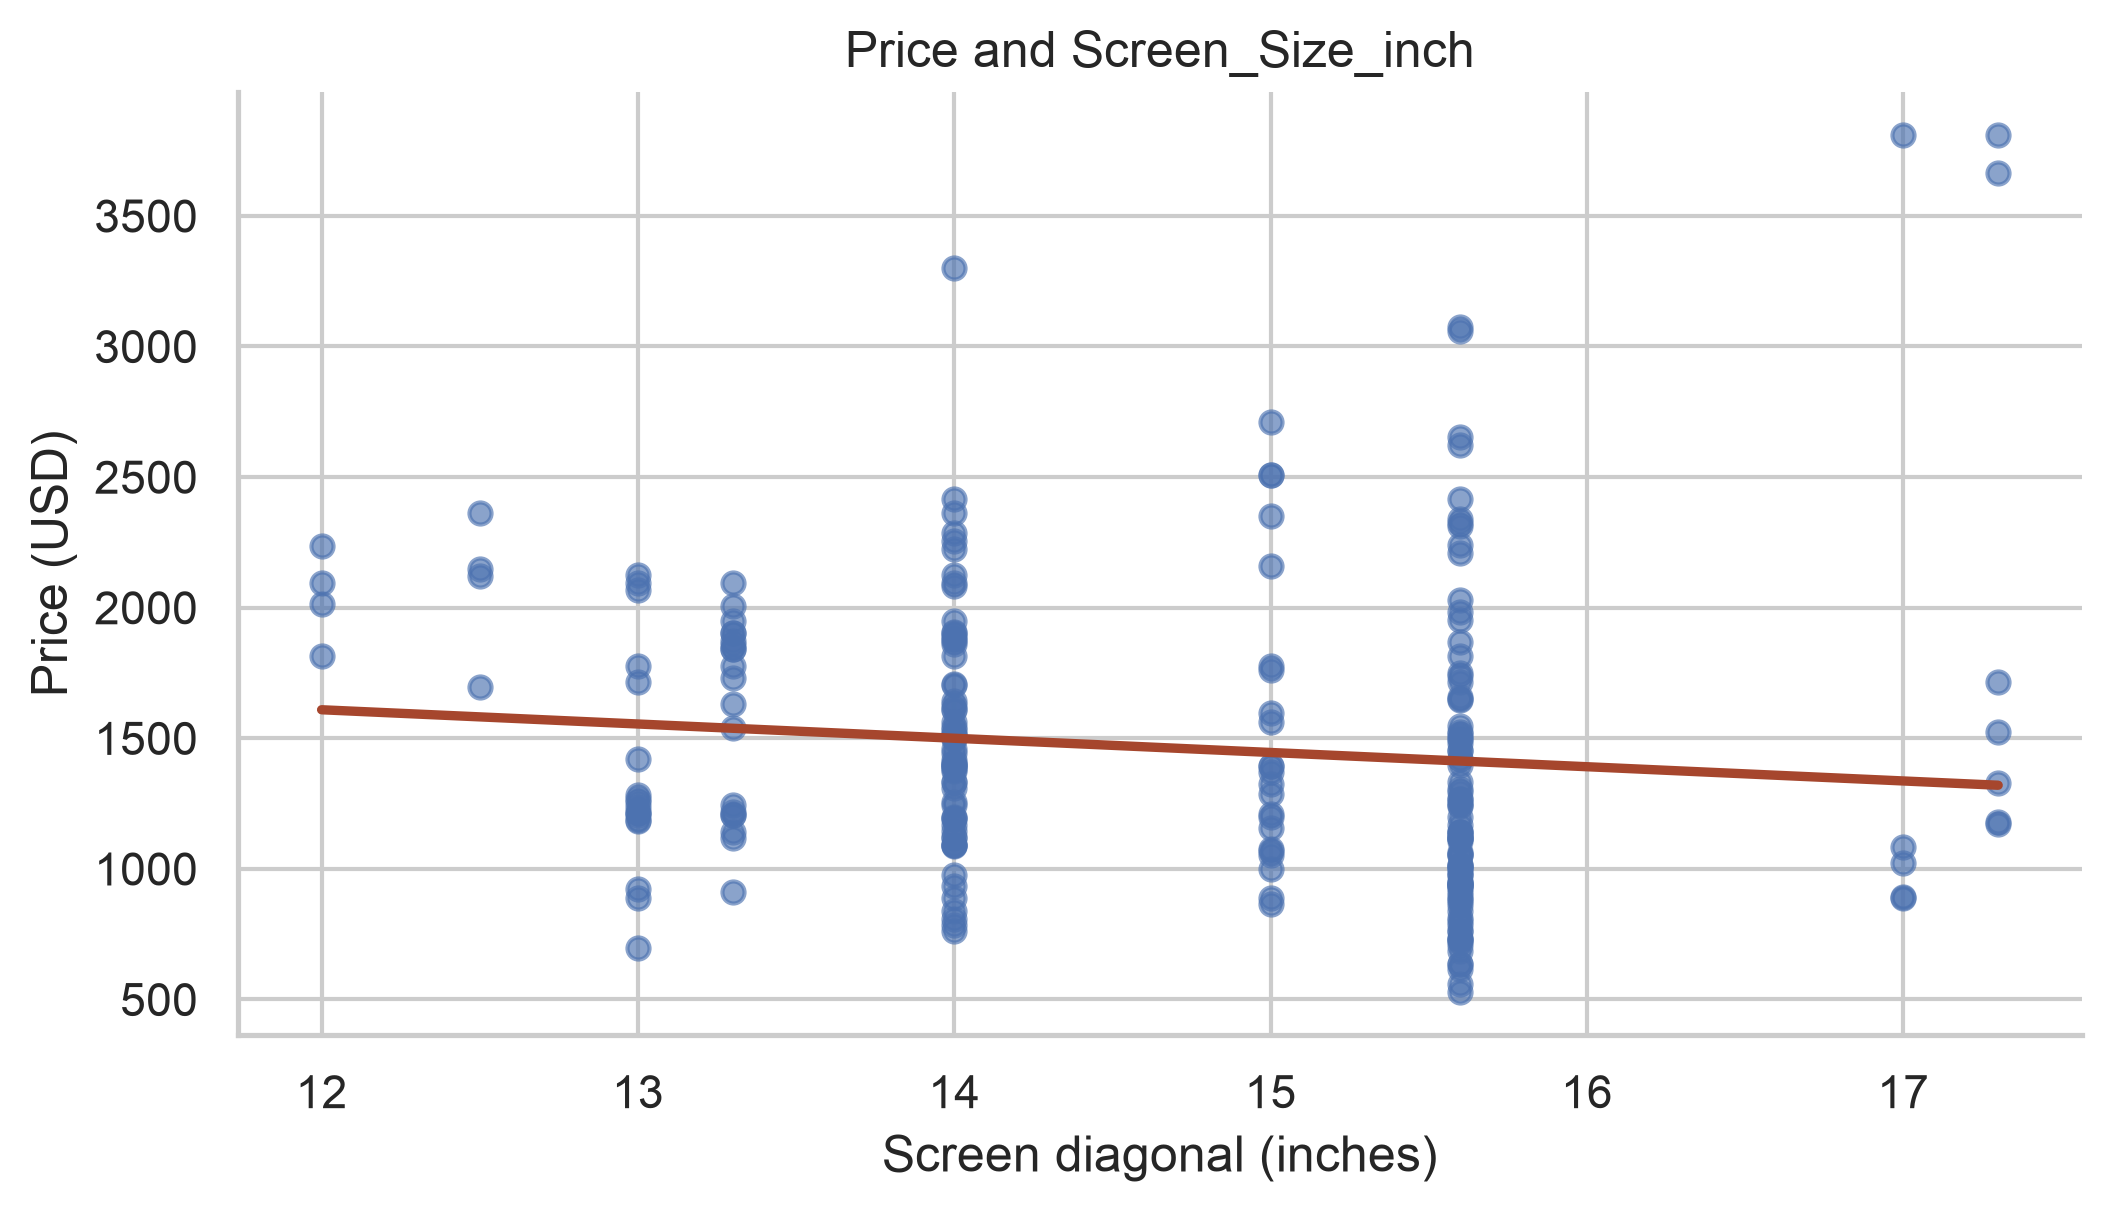

In [6]:
fig, ax = plt.subplots()
sns.regplot(data=df, x='Screen_Size_inch', y='Price', ci=None,
            scatter_kws={'alpha': 0.65, 's': 28}, line_kws={'color': '#a6462d'}, ax=ax)
ax.set(title='Price and Screen_Size_inch', xlabel='Screen diagonal (inches)', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

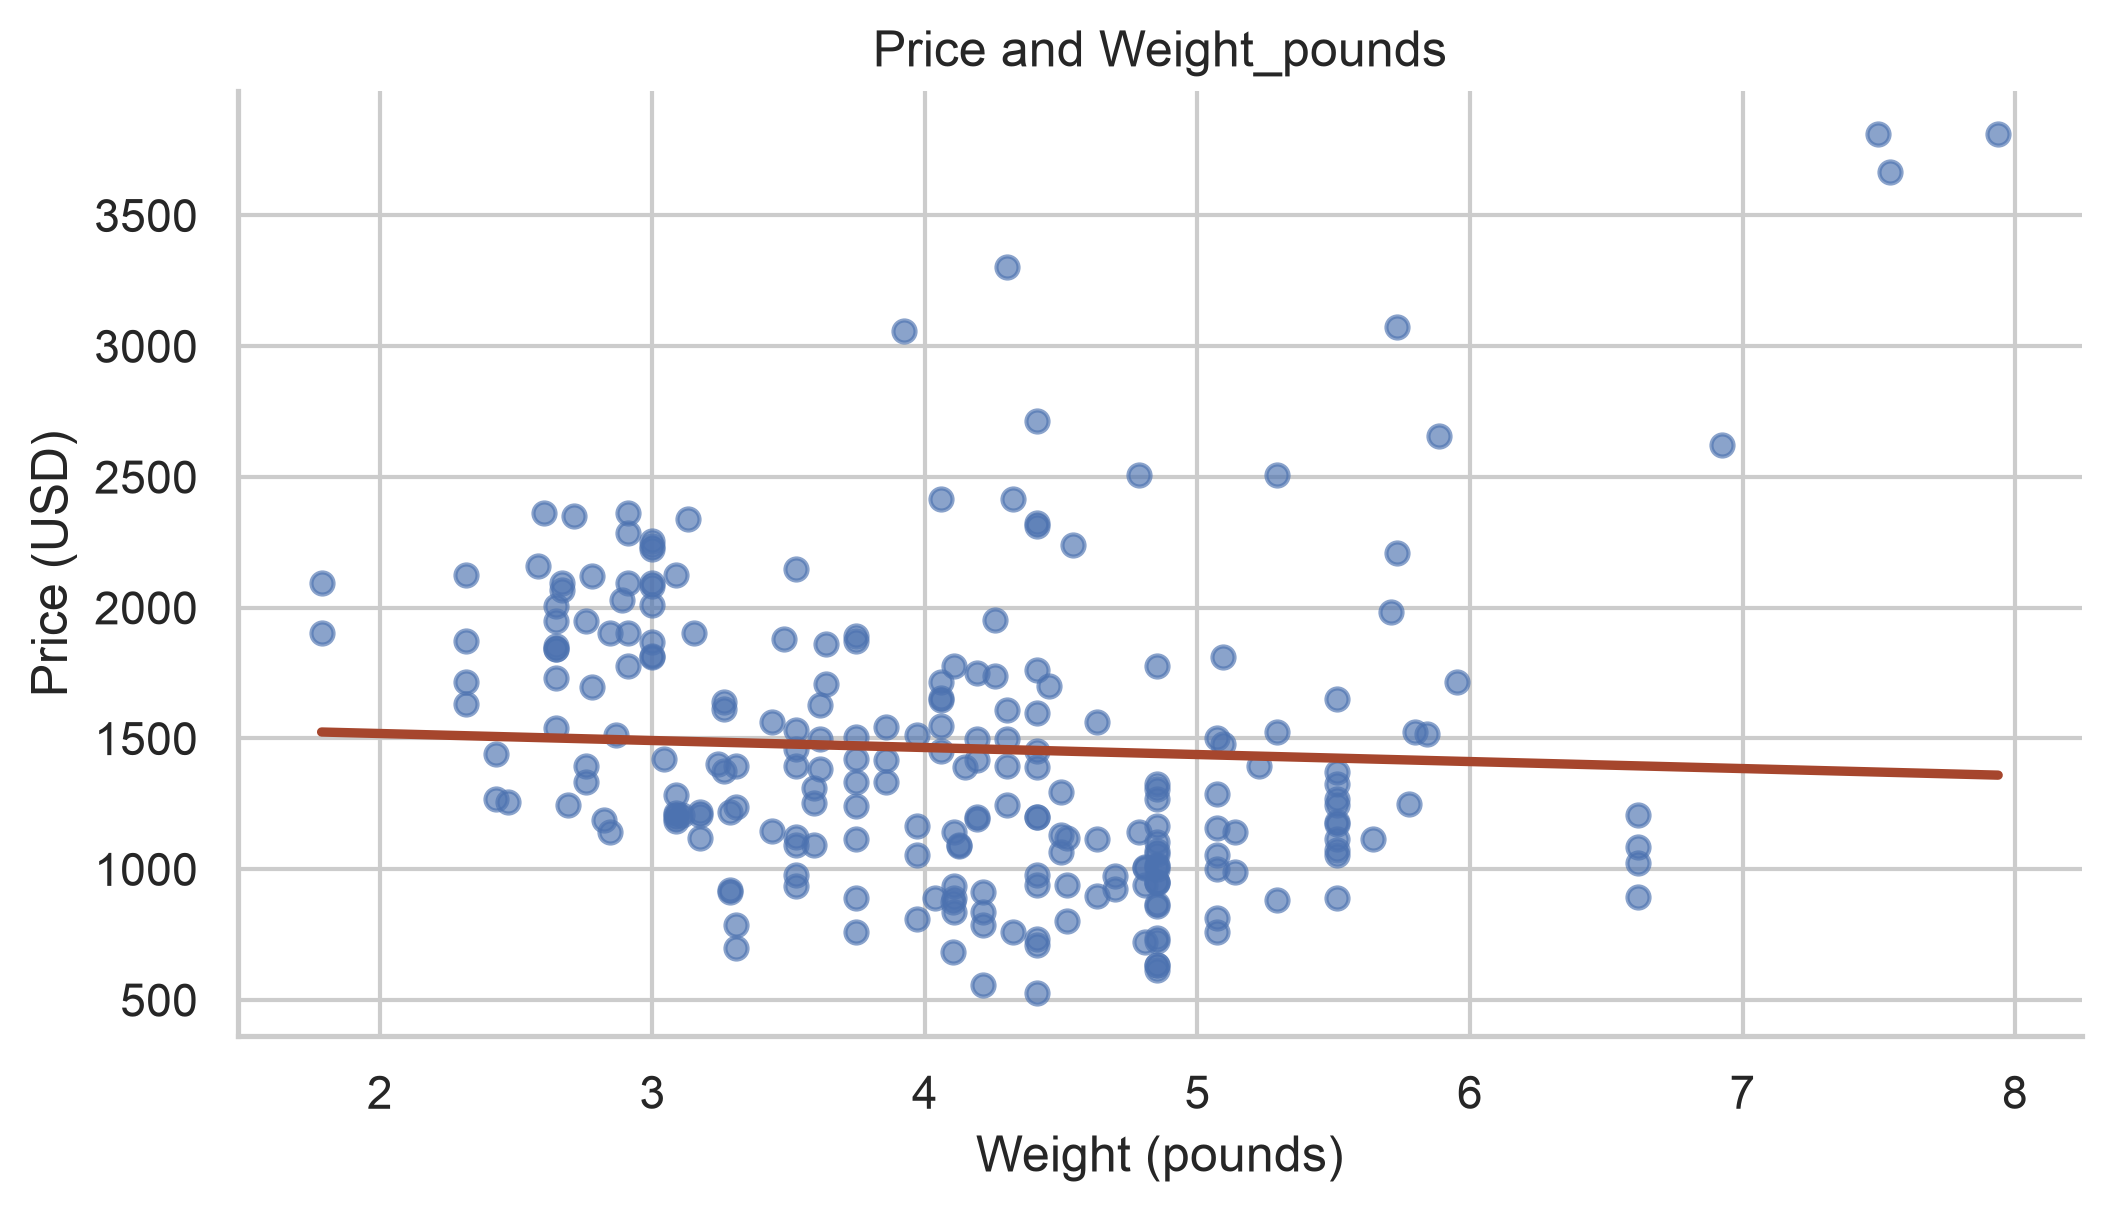

In [7]:
fig, ax = plt.subplots()
sns.regplot(data=df, x='Weight_pounds', y='Price', ci=None,
            scatter_kws={'alpha': 0.65, 's': 28}, line_kws={'color': '#a6462d'}, ax=ax)
ax.set(title='Price and Weight_pounds', xlabel='Weight (pounds)', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

In [8]:
continuous_features = ['CPU_frequency', 'Screen_Size_inch', 'Weight_pounds']
correlations = df[continuous_features + ['Price']].corr()['Price'].drop('Price')
correlations.rename('Pearson r with Price').to_frame()

,Pearson r with Price
CPU_frequency,0.3667
Screen_Size_inch,-0.1106
Weight_pounds,-0.0503


CPU frequency has a positive correlation of 0.3667 in this supplied snapshot. This is a correlation coefficient, not a percentage of price explained. Screen size and weight have substantially weaker marginal linear associations.

### Categorical features
Generate Box plots for the different feature that hold categorical values. These features would be "Category", "GPU", "OS", "CPU_core", "RAM_GB", "Storage_GB_SSD"

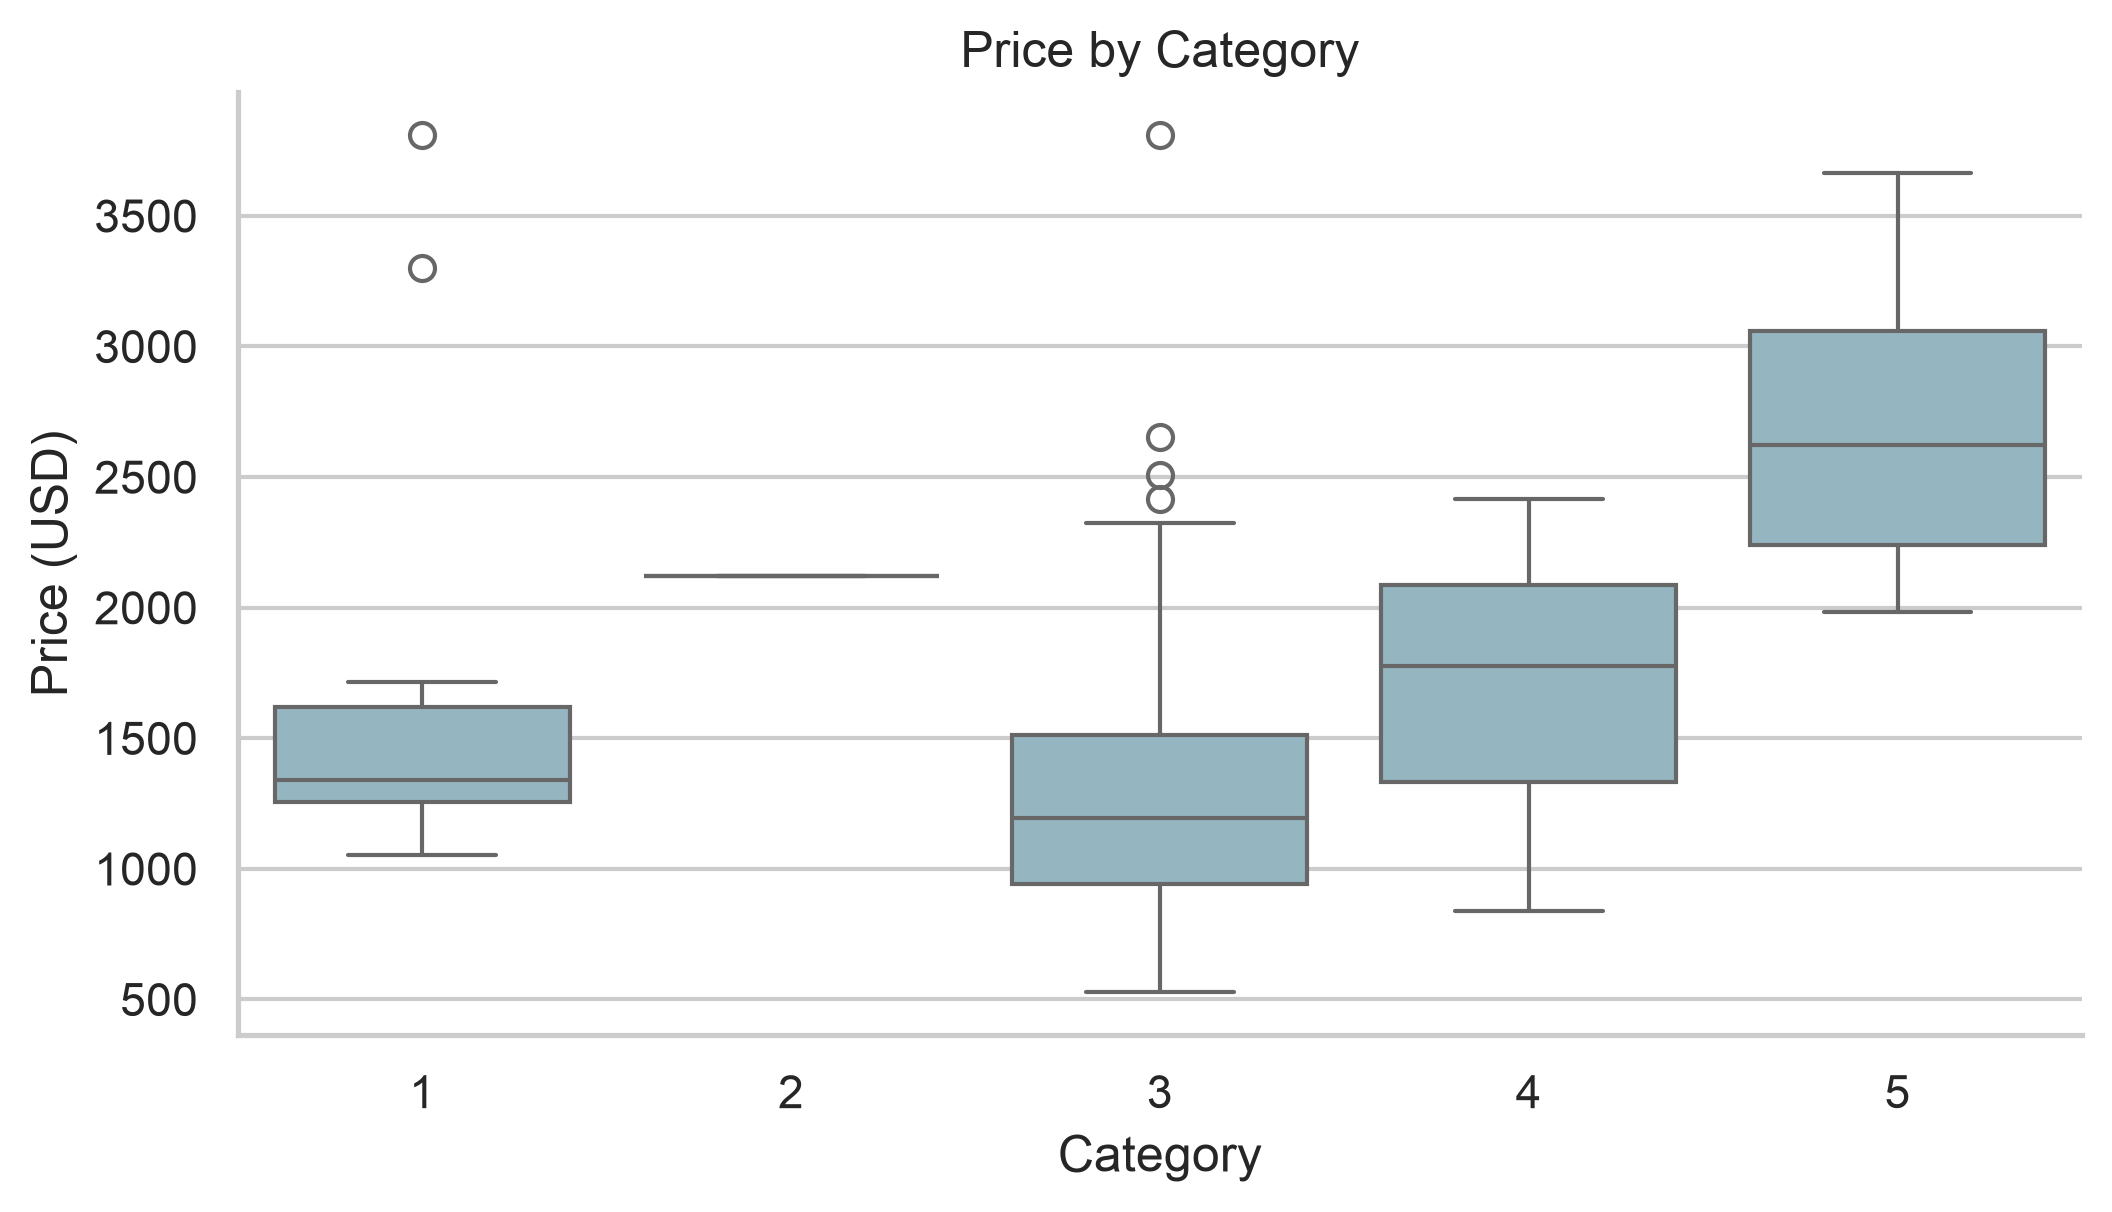

In [9]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Category', y='Price', color='#8eb9c8', ax=ax)
ax.set(title='Price by Category', xlabel='Category', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

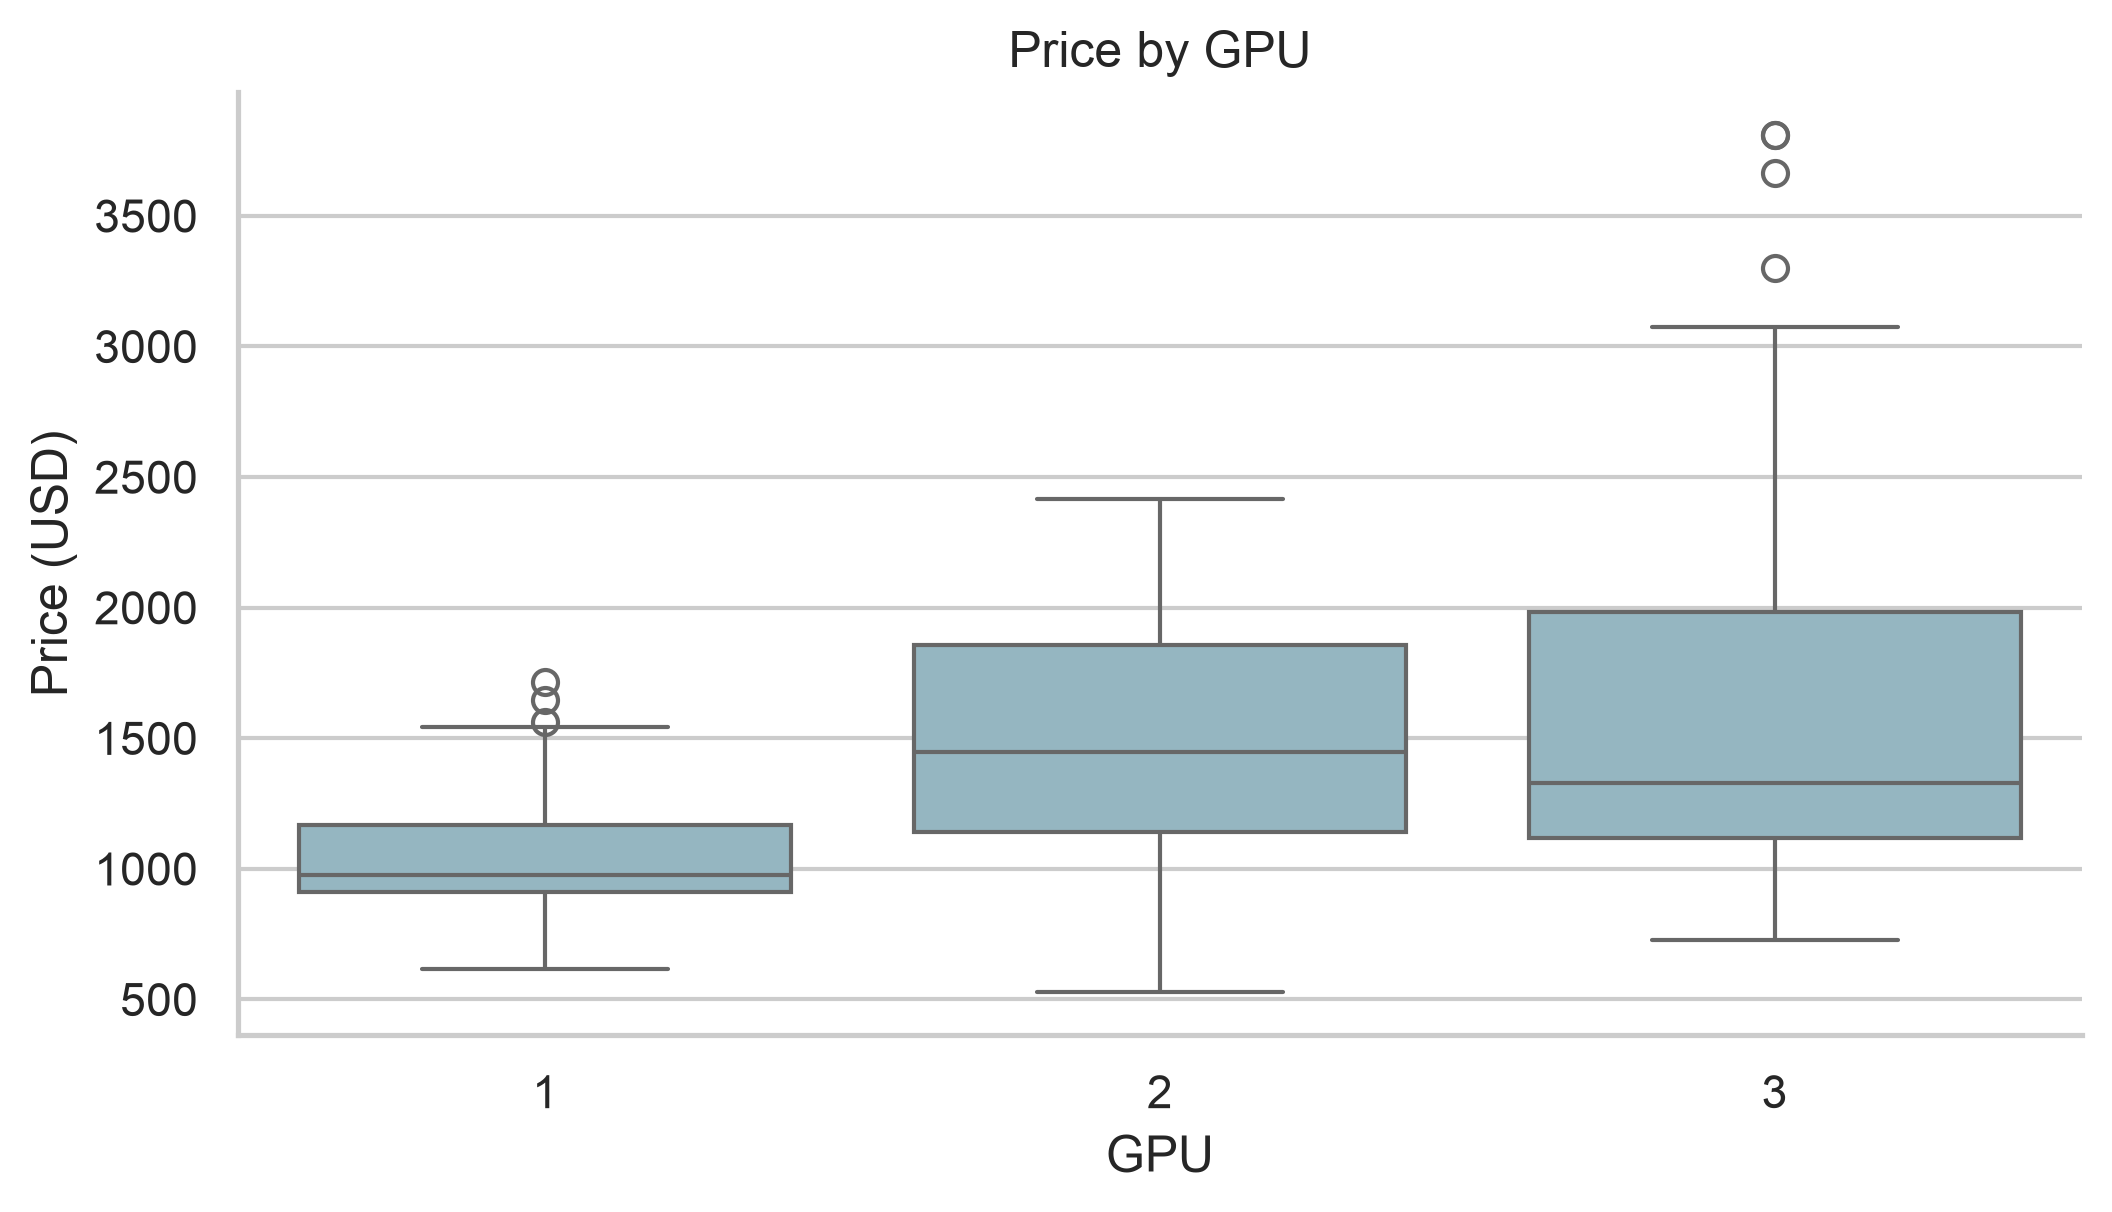

In [10]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='GPU', y='Price', color='#8eb9c8', ax=ax)
ax.set(title='Price by GPU', xlabel='GPU', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

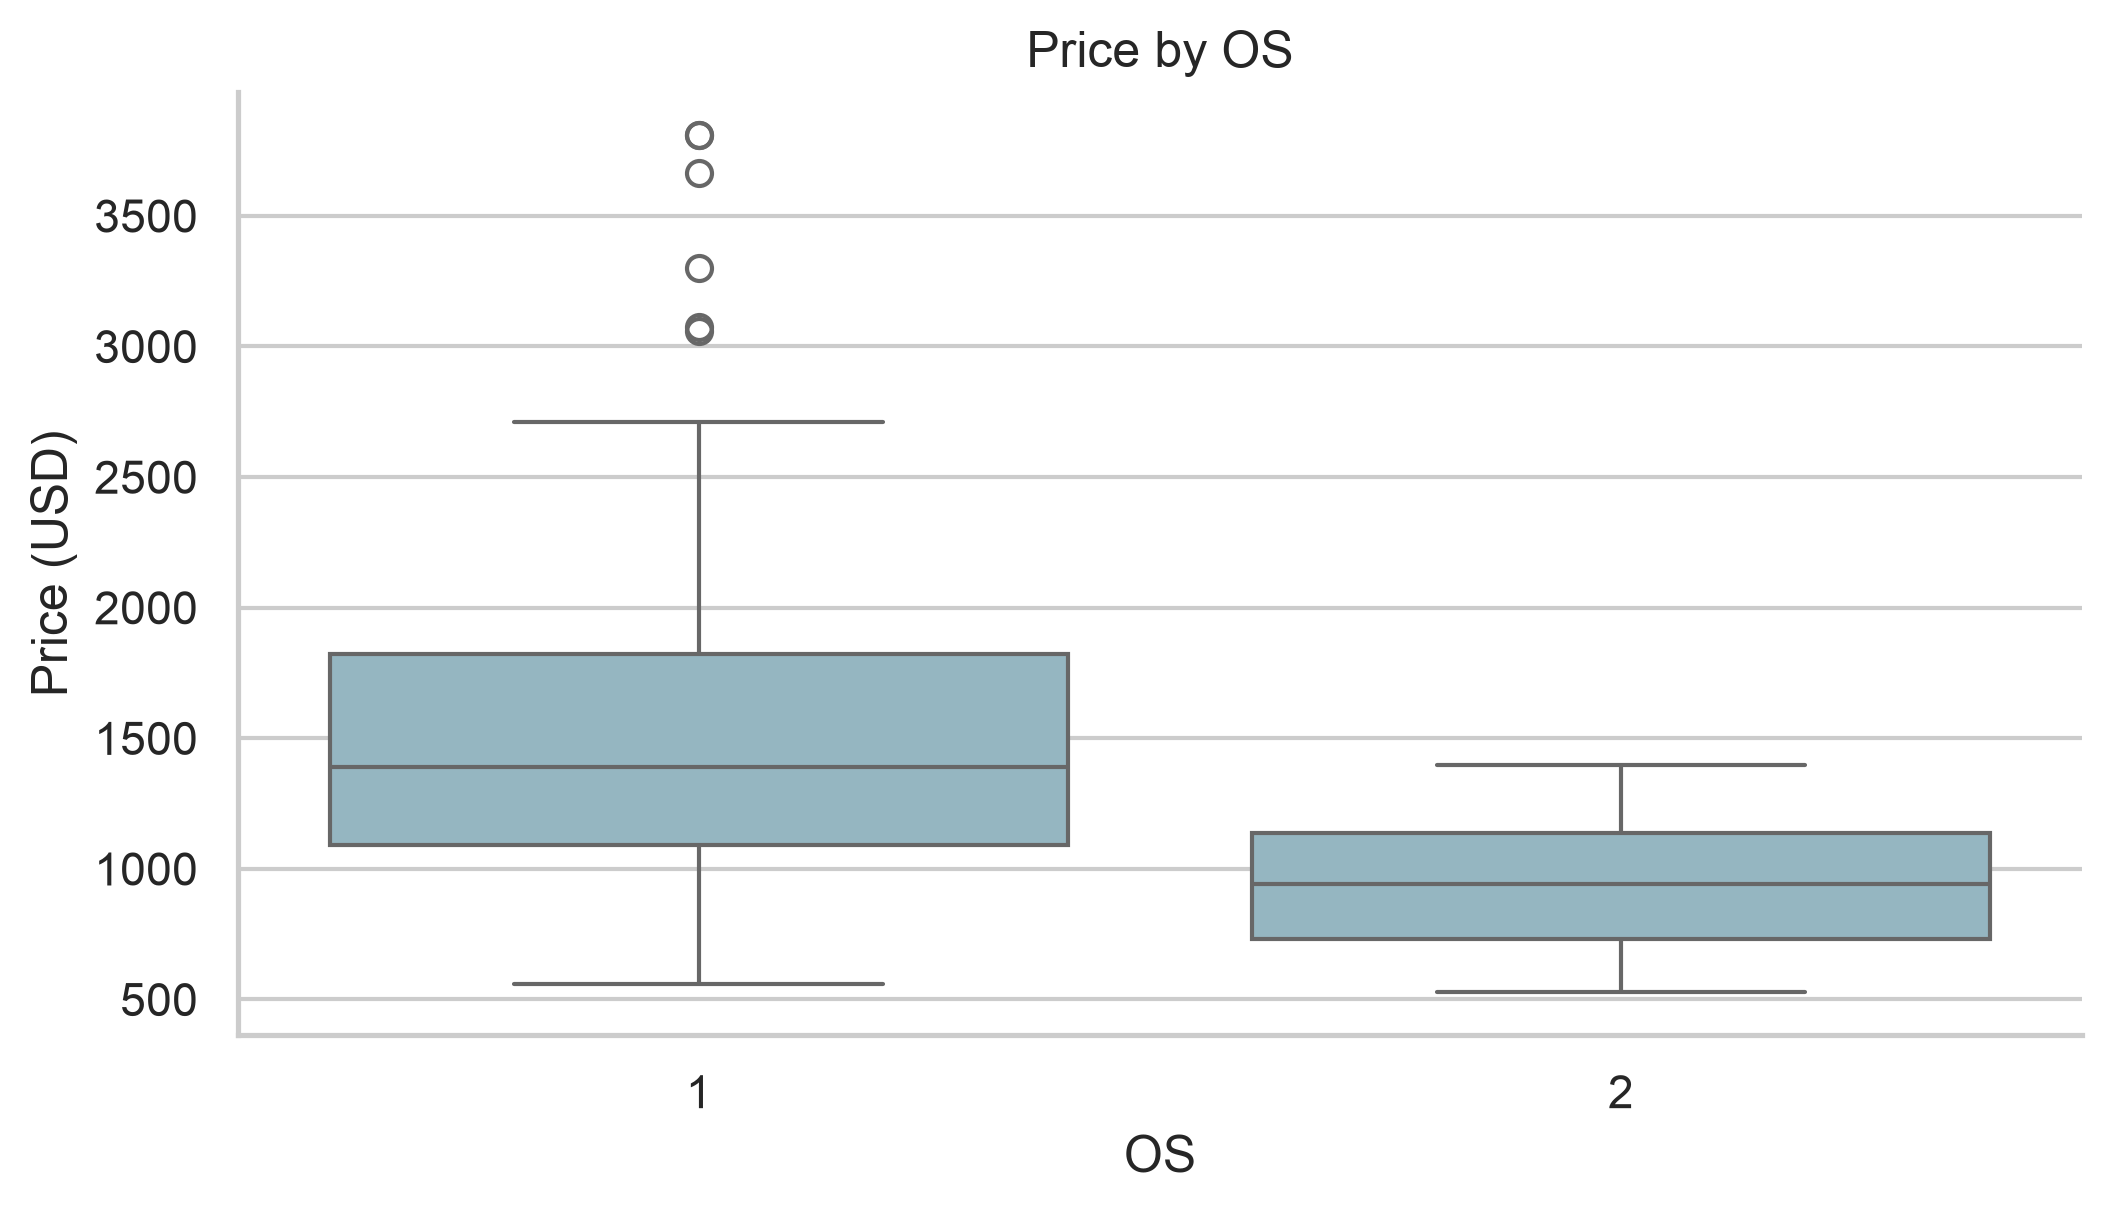

In [11]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='OS', y='Price', color='#8eb9c8', ax=ax)
ax.set(title='Price by OS', xlabel='OS', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

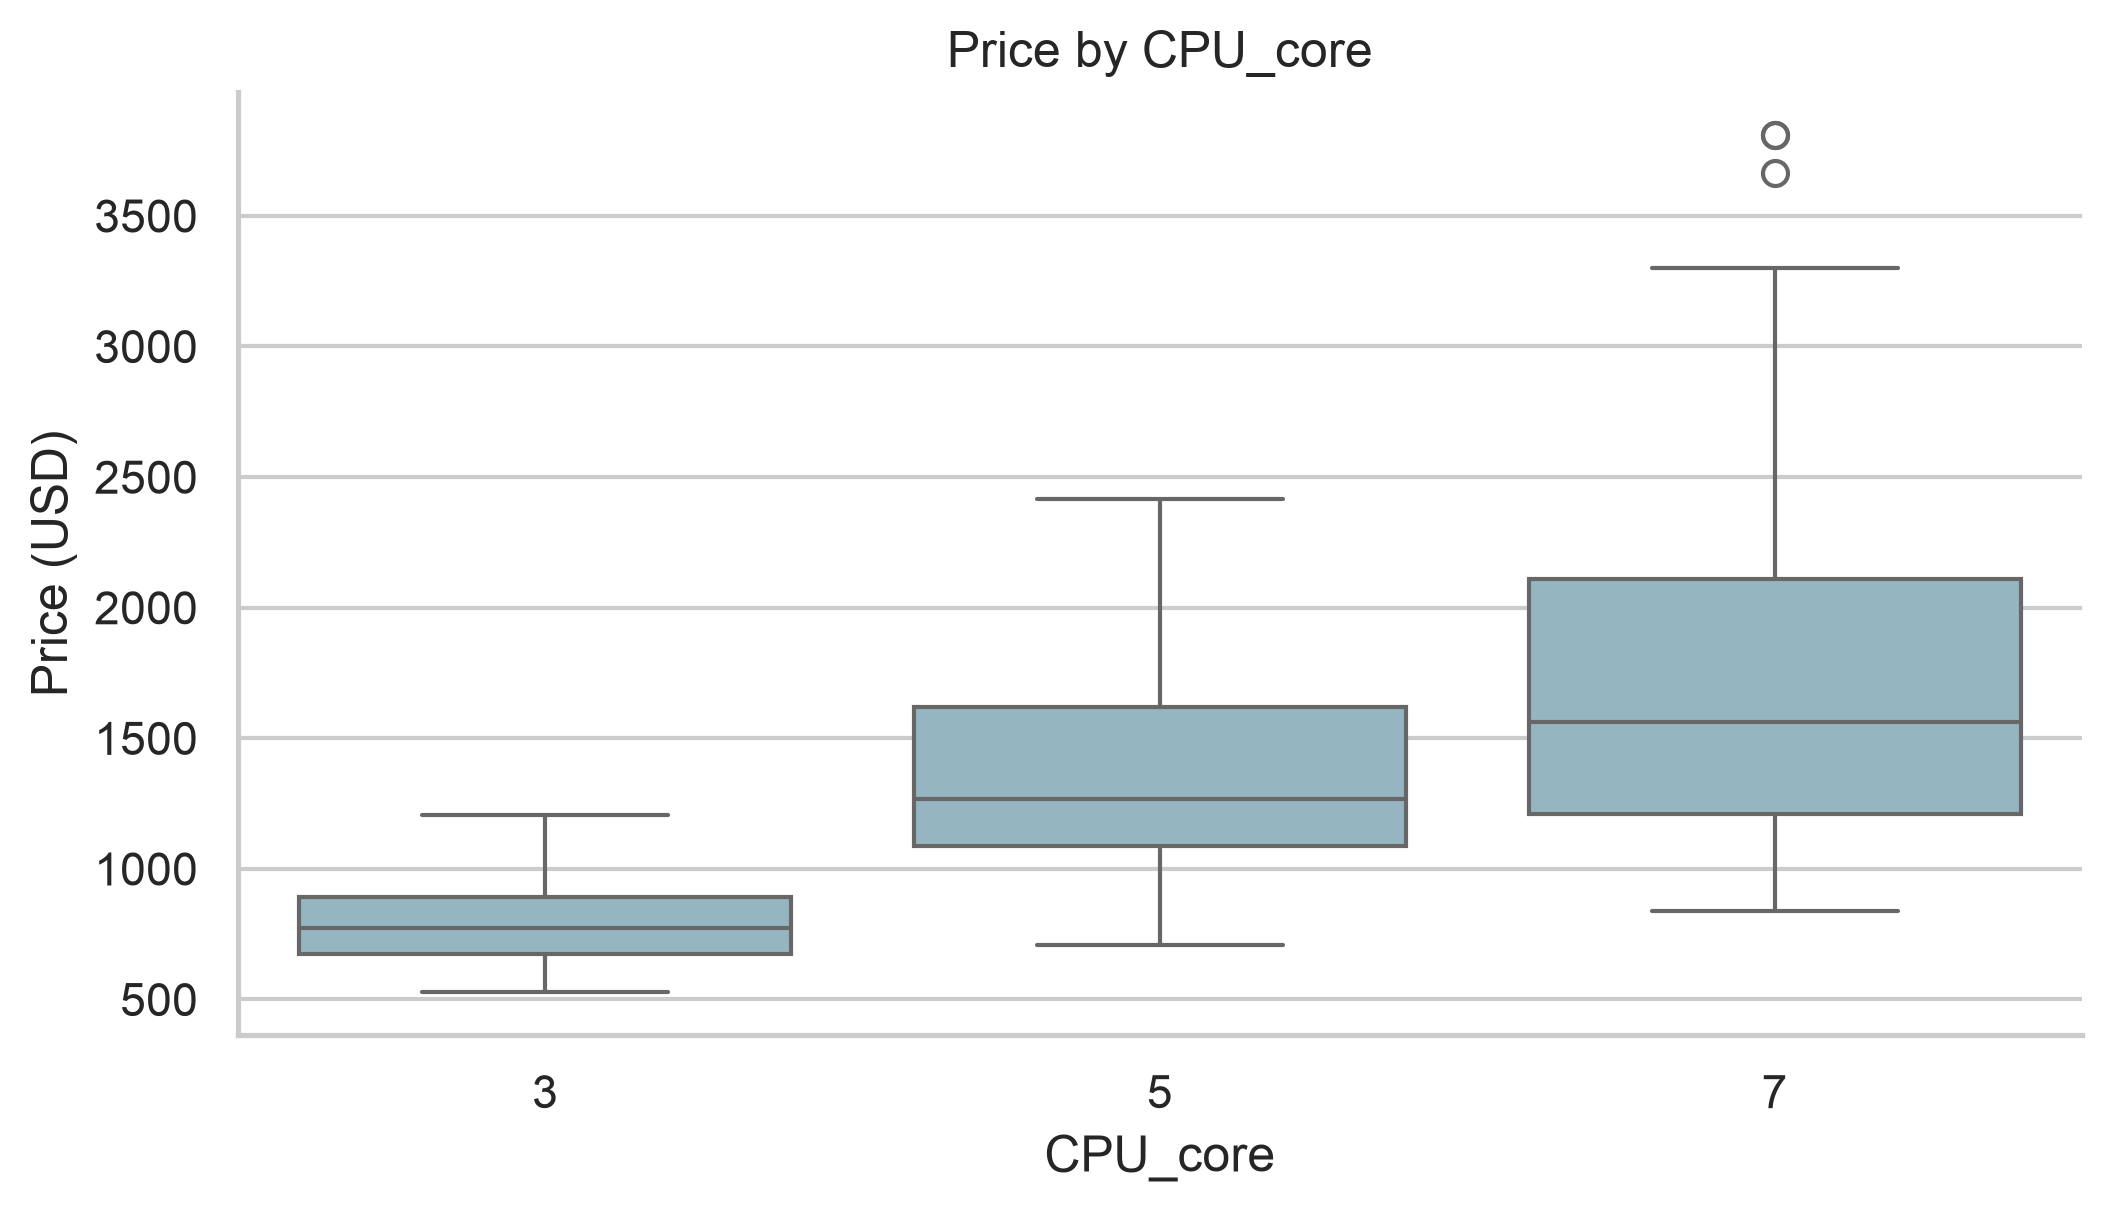

In [12]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='CPU_core', y='Price', color='#8eb9c8', ax=ax)
ax.set(title='Price by CPU_core', xlabel='CPU_core', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

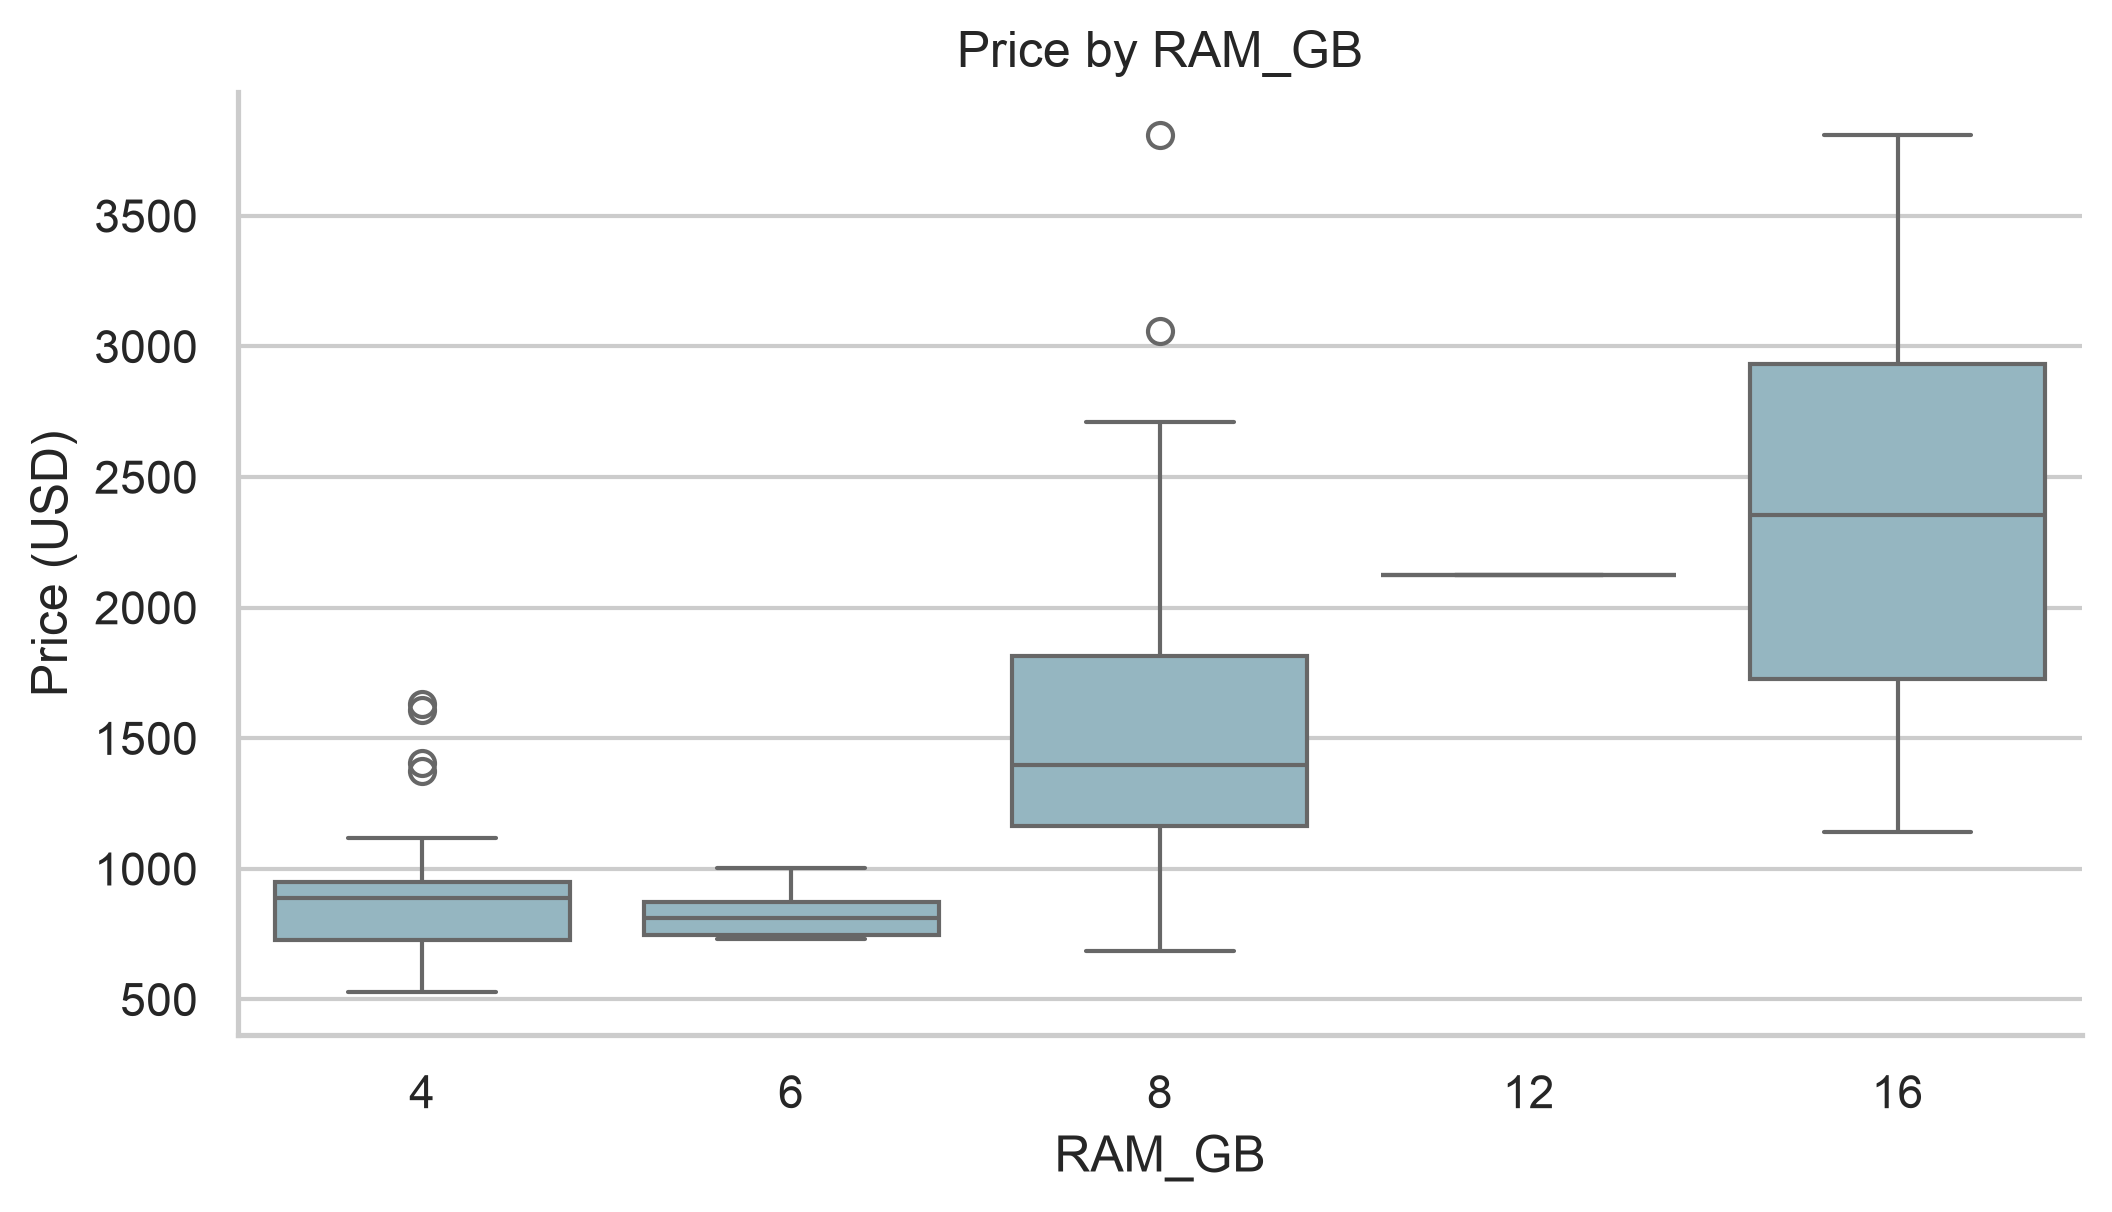

In [13]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='RAM_GB', y='Price', color='#8eb9c8', ax=ax)
ax.set(title='Price by RAM_GB', xlabel='RAM_GB', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

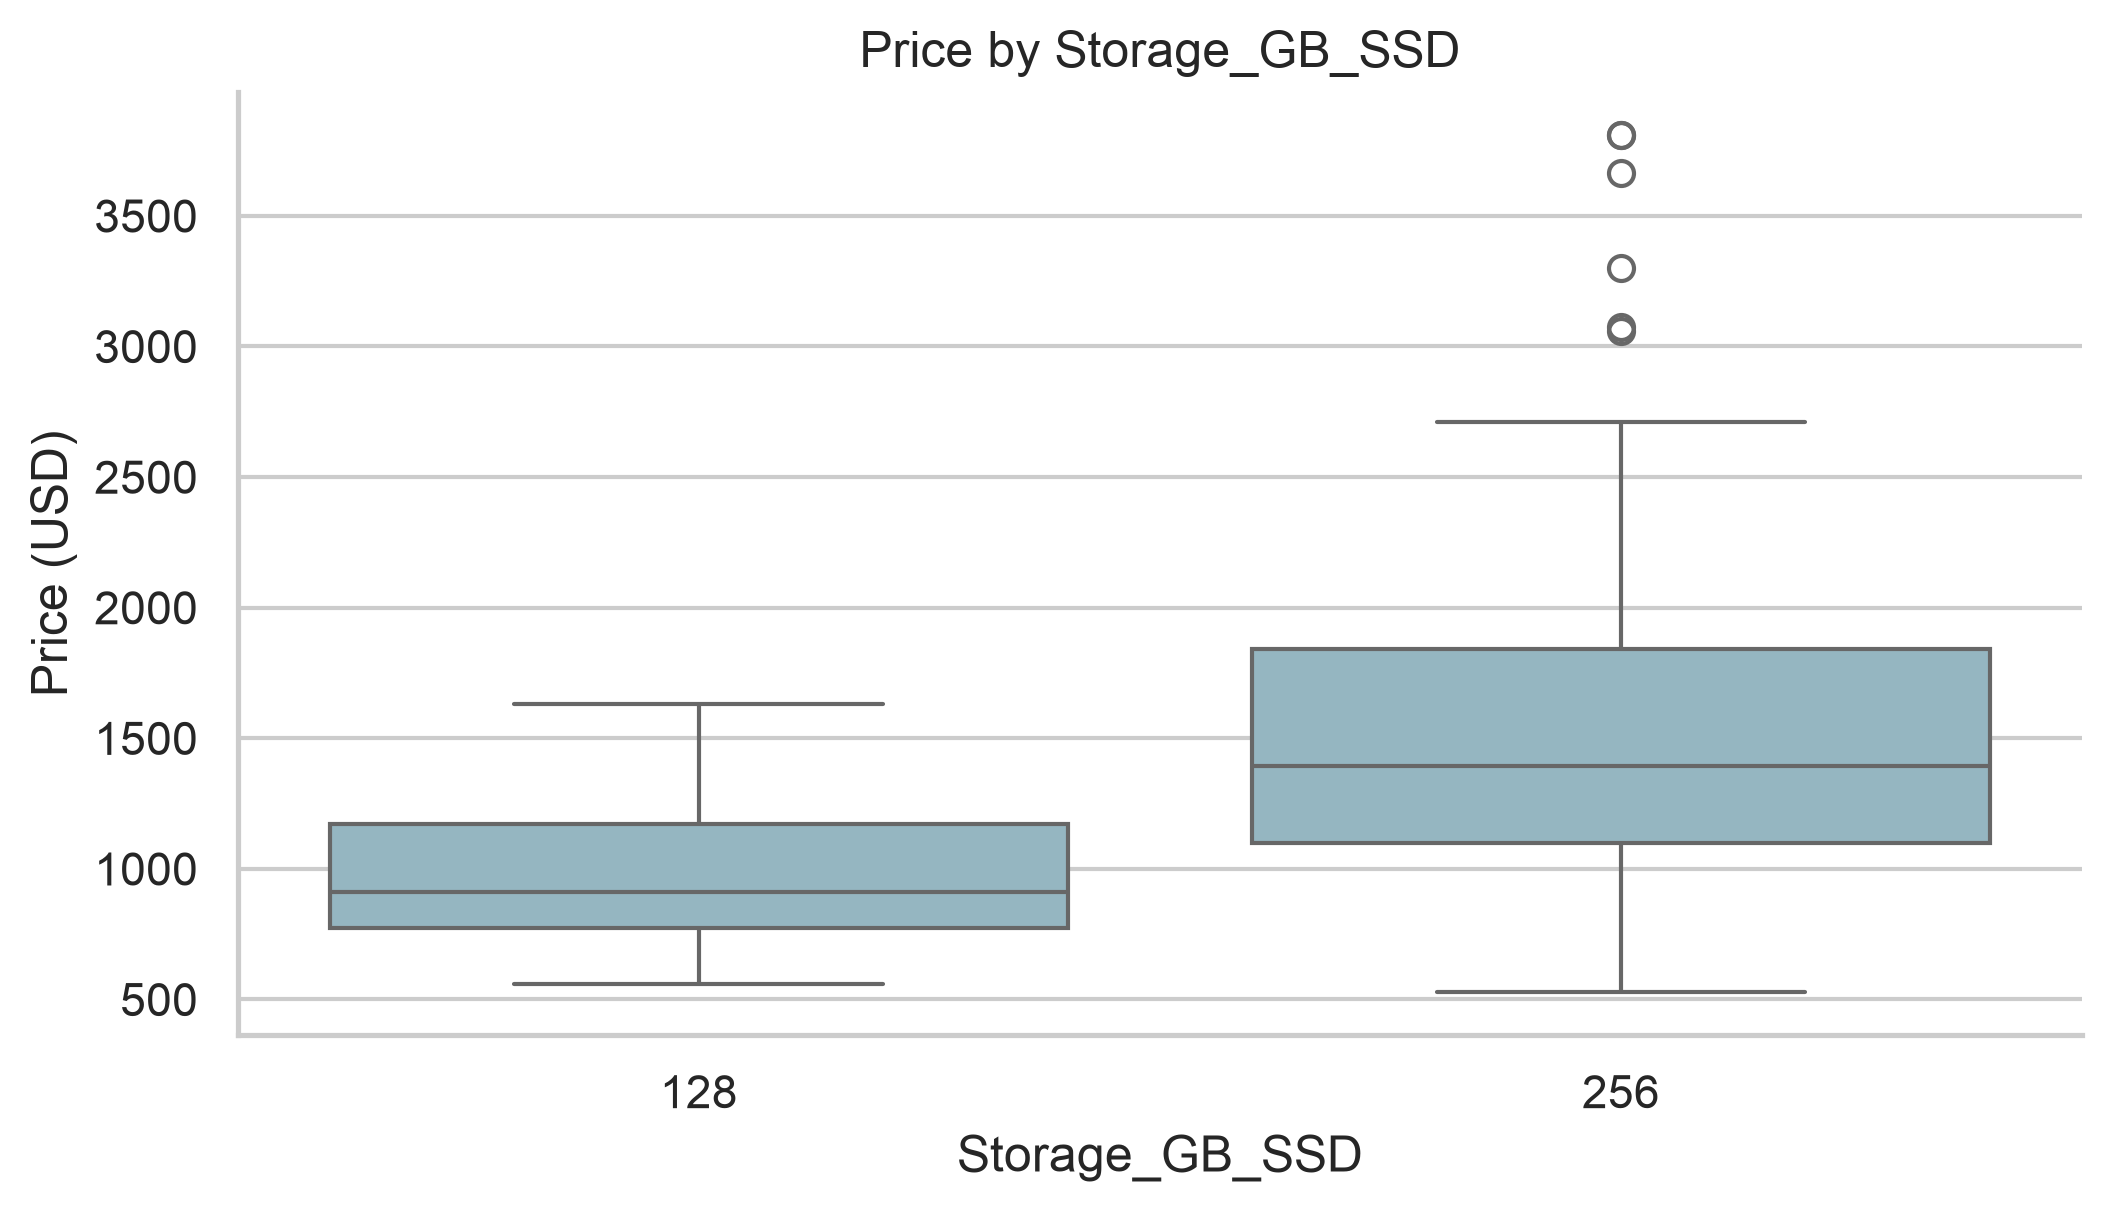

In [14]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Storage_GB_SSD', y='Price', color='#8eb9c8', ax=ax)
ax.set(title='Price by Storage_GB_SSD', xlabel='Storage_GB_SSD', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

RAM and storage have stated GB units and occur at a few configurations, making grouped boxplots useful. CPU_core takes values 3, 5 and 7; without a definitive dictionary these are treated as supplied codes, not assumed physical core counts. GPU, OS and Category likewise retain their supplied labels; code order is not a quality ranking.

# Task 2 - Descriptive Statistical Analysis

Generate the statistical description of all the features being used in the data set. Include "object" data types as well.

In [15]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Manufacturer,238,11,Dell,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,238.0,NaN,NaN,NaN,3.2059,0.7765,1.0,3.0,3.0,4.0,5.0
GPU,238.0,NaN,NaN,NaN,2.1513,0.6383,1.0,2.0,2.0,3.0,3.0
OS,238.0,NaN,NaN,NaN,1.0588,0.2358,1.0,1.0,1.0,1.0,2.0
CPU_core,238.0,NaN,NaN,NaN,5.6303,1.2418,3.0,5.0,5.0,7.0,7.0
Screen_Size_inch,238.0,NaN,NaN,NaN,14.6887,1.166,12.0,14.0,15.0,15.6,17.3
CPU_frequency,238.0,NaN,NaN,NaN,0.8138,0.1419,0.4138,0.6897,0.8621,0.931,1.0
RAM_GB,238.0,NaN,NaN,NaN,7.8824,2.4826,4.0,8.0,8.0,8.0,16.0
Storage_GB_SSD,238.0,NaN,NaN,NaN,245.7815,34.7653,128.0,256.0,256.0,256.0,256.0
Weight_pounds,238.0,NaN,NaN,NaN,4.1062,1.0784,1.786,3.2469,4.1062,4.851,7.938


The all-type summary includes the derived price band. Its group frequencies describe this sample only; the band contains the target's information. Numeric category codes should be read with the grouped plots rather than interpreted as continuous quantities.

# Task 3 - GroupBy and Pivot Tables

Group the parameters "GPU", "CPU_core" and "Price" to make a pivot table and visualize this connection using the pcolor plot.

In [16]:
df_gptest = df[['GPU', 'CPU_core', 'Price']]
grouped_test1 = df_gptest.groupby(['GPU', 'CPU_core'], as_index=False)['Price'].mean()
display(grouped_test1)
display(df_gptest.groupby(['GPU', 'CPU_core']).size().rename('n').to_frame())

,GPU,CPU_core,Price
0,1,3,769.2500
1,1,5,998.5000
2,1,7,1167.9412
3,2,3,785.0769
4,2,5,1462.1977
5,2,7,1744.6216
6,3,3,784.0000
7,3,5,1220.6800
8,3,7,1945.0976


n
GPU CPU_core    
1   3          4
    5         12
    7         17
2   3         13
    5         86
    7         37
3   3          3
    5         25
    7         41

In [17]:
grouped_pivot = grouped_test1.pivot(index='GPU', columns='CPU_core', values='Price')
grouped_pivot

CPU_core,3,5,7
GPU,,,
1,769.2500,998.5000,1167.9412
2,785.0769,1462.1977,1744.6216
3,784.0000,1220.6800,1945.0976


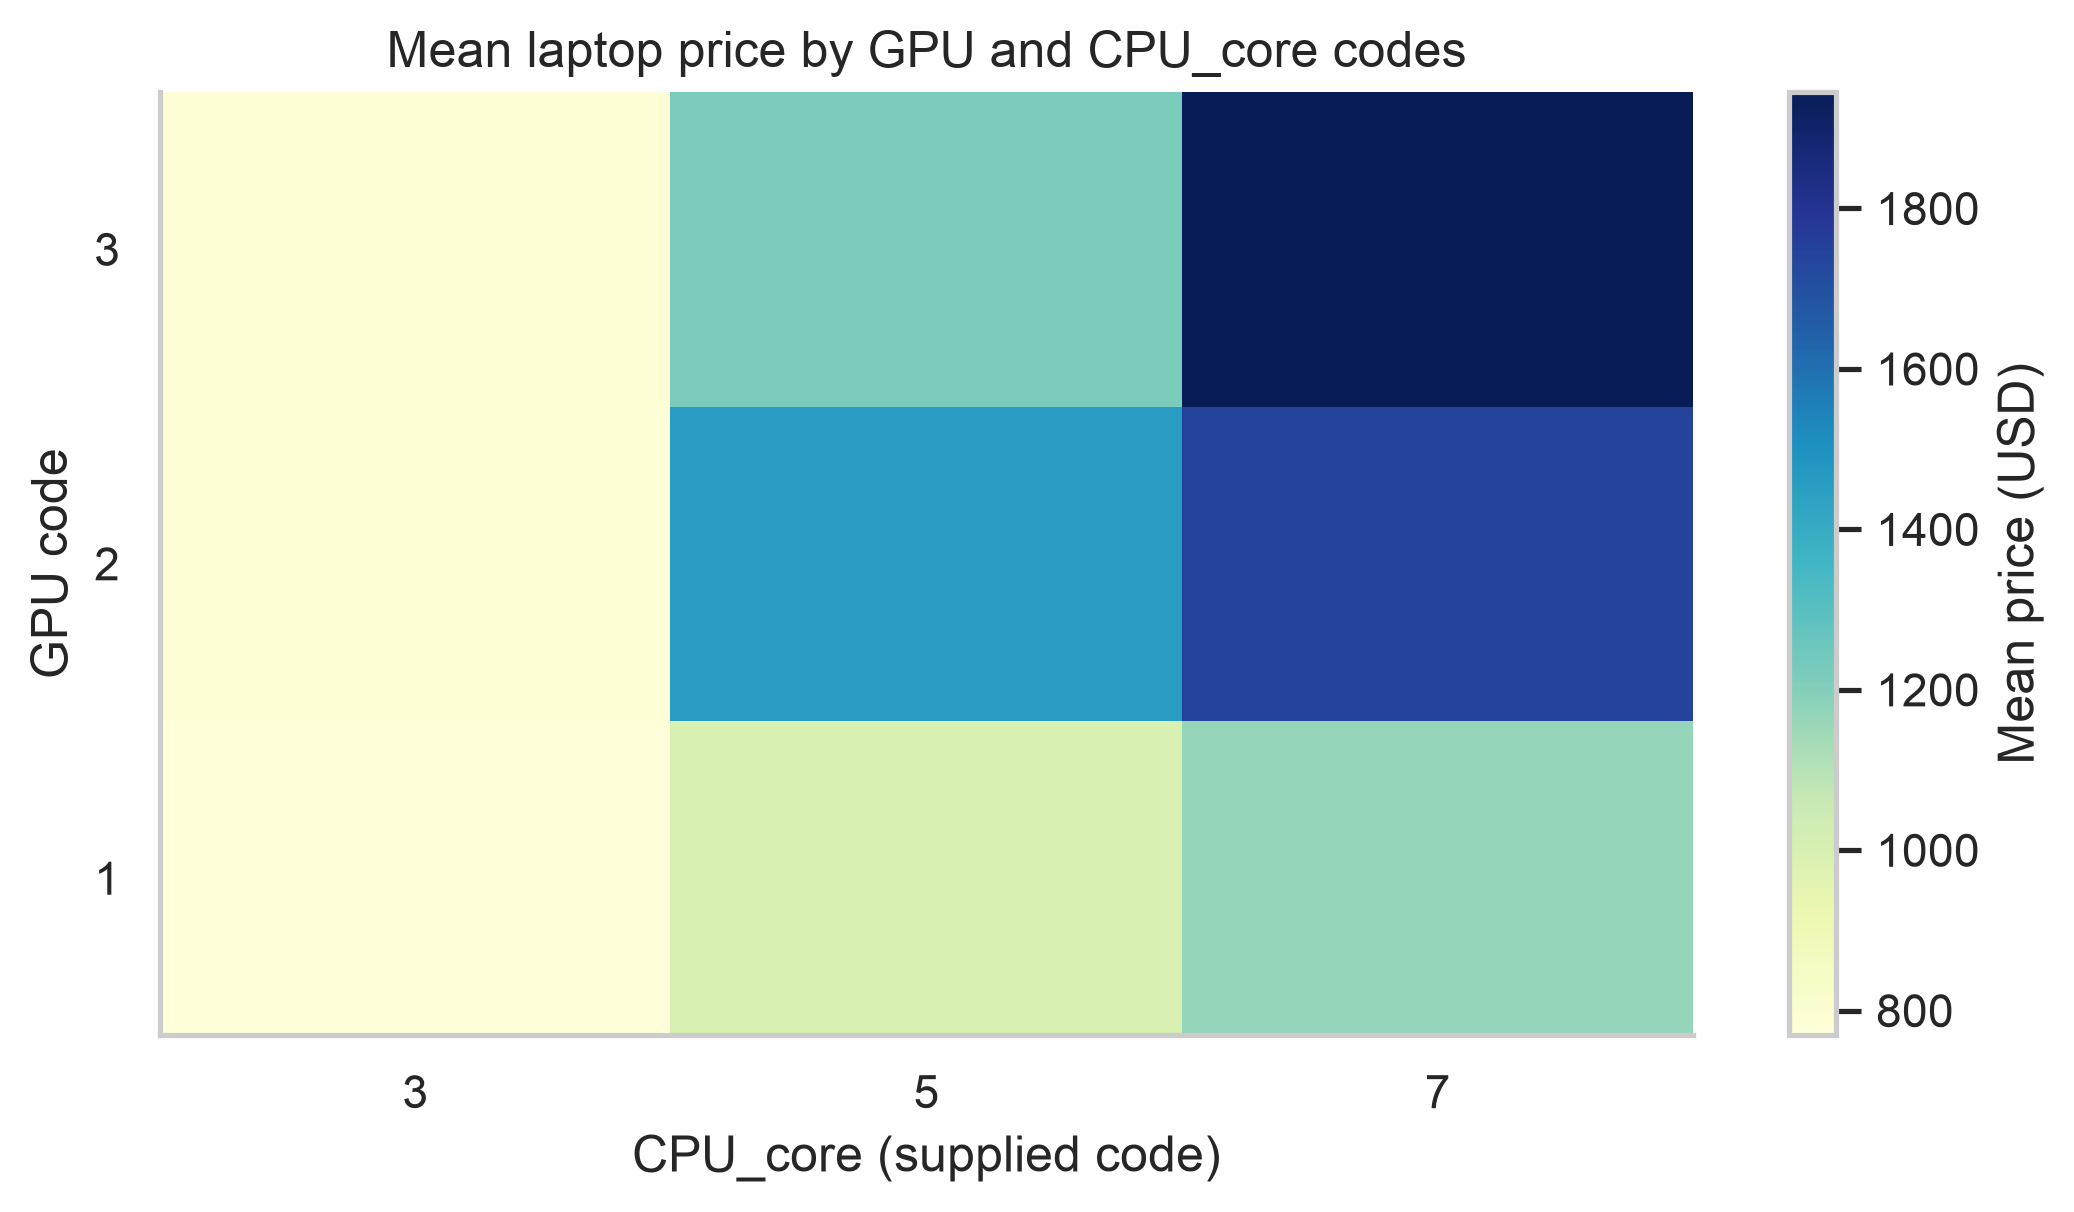

In [18]:
fig, ax = plt.subplots()
im = ax.pcolor(np.ma.masked_invalid(grouped_pivot.to_numpy()), cmap='YlGnBu')
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, labels=grouped_pivot.columns)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, labels=grouped_pivot.index)
ax.set(title='Mean laptop price by GPU and CPU_core codes', xlabel='CPU_core (supplied code)', ylabel='GPU code')
fig.colorbar(im, ax=ax, label='Mean price (USD)')
fig.tight_layout()
plt.show()

All nine GPU/CPU_core combinations are observed, with group sizes ranging from 3 to 86. Means based on the smaller groups are less stable. Differences may also reflect RAM, manufacturer or other specifications.

# Task 4 - Pearson Correlation and p-values

Use `scipy.stats.pearsonr()` to evaluate the coefficient and p-value for the nine requested features. These tests describe marginal linear association. GPU, OS and Category are nominal codes, and the precise meaning of CPU_core codes is undocumented here. The correlations of nominal codes depend on the arbitrary coding and cannot be interpreted as numerical effects of a one-unit category increase.

In [19]:
features = ['RAM_GB', 'CPU_frequency', 'Storage_GB_SSD', 'Screen_Size_inch', 'Weight_pounds', 'CPU_core', 'OS', 'GPU', 'Category']
pearson_rows = []
for feature in features:
    pair = df[[feature, 'Price']].dropna()
    r, p = stats.pearsonr(pair[feature], pair['Price'])
    pearson_rows.append({'Feature': feature, 'n': len(pair), 'Pearson r': r, 'p-value': p})
pearson_summary = pd.DataFrame(pearson_rows).set_index('Feature')
display(pearson_summary.style.format({'Pearson r': '{:.4f}', 'p-value': '{:.3e}'}))

,n,Pearson r,p-value
Feature,,,
RAM_GB,238,0.5493,3.682e-20
CPU_frequency,238,0.3667,5.502e-09
Storage_GB_SSD,238,0.2434,1.490e-04
Screen_Size_inch,238,-0.1106,8.853e-02
Weight_pounds,238,-0.0503,4.398e-01
CPU_core,238,0.4594,7.913e-14
OS,238,-0.2217,5.697e-04
GPU,238,0.2883,6.167e-06
Category,238,0.2862,7.226e-06


RAM has the strongest positive marginal correlation among these requested measurements. CPU frequency is more moderately associated; screen size and weight are weak on their own. Small p-values are not measures of effect size, and these exploratory tests are not adjusted for multiple comparisons. Hardware characteristics also co-vary, so a later multivariable model needs validation before these patterns can support price prediction.

## Authors

[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)

Copyright © 2023 IBM Corporation. All rights reserved.

## Tool acknowledgement

OpenAI Codex assisted with code completion, debugging and explanation drafting. Numerical results and figures were generated by executing the notebook in the recorded local Python environment. The collaborators are responsible for reviewing the analysis and submitted material. [OpenAI Codex](https://openai.com/codex/) (accessed 15 September 2026).